Saving kc_house_data.csv to kc_house_data (1).csv
Original number of rows: 21613
Original columns: ['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15']

Number of rows after cleaning: 21613
              price   sqft_living      bedrooms     bathrooms
count  2.161300e+04  21613.000000  21613.000000  21613.000000
mean   5.400881e+05   2079.899736      3.370842      2.114757
std    3.671272e+05    918.440897      0.930062      0.770163
min    7.500000e+04    290.000000      0.000000      0.000000
25%    3.219500e+05   1427.000000      3.000000      1.750000
50%    4.500000e+05   1910.000000      3.000000      2.250000
75%    6.450000e+05   2550.000000      4.000000      2.500000
max    7.700000e+06  13540.000000     33.000000      8.000000

Training set: 12967 records, Validation set: 4323 records,

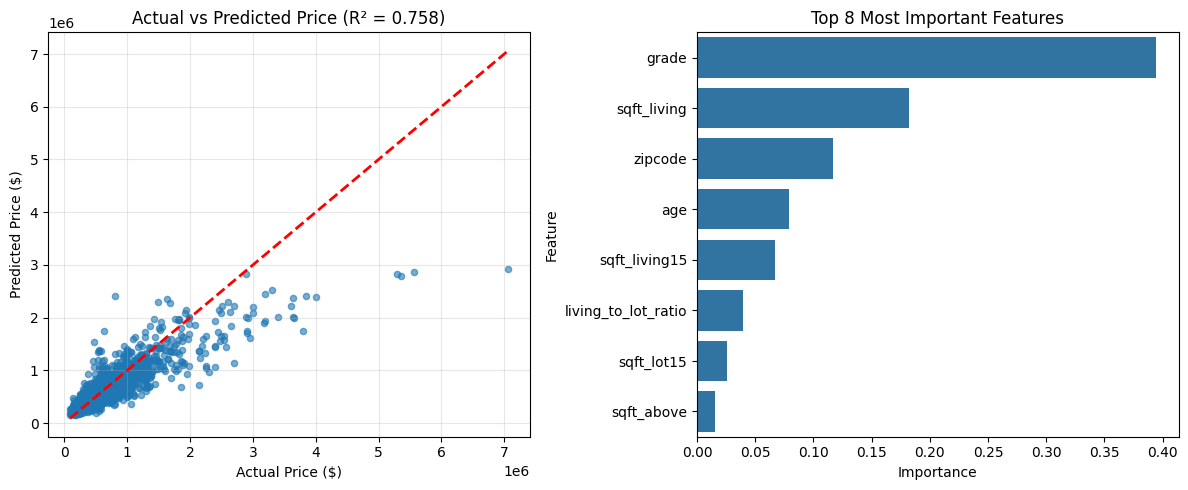


Mean Absolute Error: $100,504.84
Median Absolute Error: $56,455.23

Error Analysis by Price Range:
                       Absolute_Error             Actual
                                 mean      median  count
price                                                   
(82977.45, 1484460.0]        82934.56    54570.96   4203
(1484460.0, 2878970.0]      524247.58   456238.27     96
(2878970.0, 4273480.0]     1185567.08  1267368.64     20
(4273480.0, 5667990.0]     2577024.89  2557183.56      3
(5667990.0, 7062500.0]     4138293.61  4138293.61      1


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from google.colab import files
import warnings
warnings.filterwarnings('ignore')


uploaded = files.upload()
path = list(uploaded.keys())[0]
df = pd.read_csv(path, encoding_errors="ignore")

print(f"Original number of rows: {len(df)}")
print("Original columns:", df.columns.tolist())

#data cleaning
df_model = df.copy()

df_model['date'] = pd.to_datetime(df_model['date'], errors='coerce')
df_model['year'] = df_model['date'].dt.year
df_model['month'] = df_model['date'].dt.month

drop_cols = ['id', 'date']
drop_cols = [col for col in drop_cols if col in df_model.columns]
df_model = df_model.drop(columns=drop_cols)

df_model = df_model.dropna()

df_model = df_model[df_model['price'] > 0]

print("\nNumber of rows after cleaning:", len(df_model))
print(df_model.describe()[['price', 'sqft_living', 'bedrooms', 'bathrooms']])


# Feature
df_model['age'] = 2014 - df_model['yr_built']
df_model['is_renovated'] = (df_model['yr_renovated'] > 0).astype(int)
df_model['total_rooms'] = df_model['bedrooms'] + df_model['bathrooms']
df_model['living_to_lot_ratio'] = df_model['sqft_living'] / df_model['sqft_lot']
df_model['sqft_per_floor'] = df_model['sqft_living'] / df_model['floors']


core_features = [
    'sqft_living', 'bathrooms', 'bedrooms', 'sqft_lot',
    'floors', 'waterfront', 'view', 'condition', 'grade',
    'sqft_above', 'sqft_basement',
    'age', 'is_renovated', 'total_rooms', 'living_to_lot_ratio', 'sqft_per_floor',
    'zipcode', 'year', 'month', 'sqft_living15', 'sqft_lot15'
]


core_features = [f for f in core_features if f in df_model.columns]

X = df_model[core_features]
y = df_model['price']


y_log = np.log1p(y)

# Divide training and testing sets

X_train, X_temp, y_train_log, y_temp_log = train_test_split(
    X, y_log, test_size=0.4, random_state=42
)

X_val, X_test, y_val_log, y_test_log = train_test_split(
    X_temp, y_temp_log, test_size=0.5, random_state=42
)

print(f"\nTraining set: {len(X_train)} records, Validation set: {len(X_val)} records, Test set: {len(X_test)} records")


categorical_cols = ['zipcode']
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_val[col] = X_val[col].astype(str).map(lambda s: le.transform([s])[0] if s in le.classes_ else -1)
    X_test[col] = X_test[col].astype(str).map(lambda s: le.transform([s])[0] if s in le.classes_ else -1)
    label_encoders[col] = le


numeric_cols = [c for c in core_features if c not in categorical_cols]
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[numeric_cols])
X_val_scaled = scaler.transform(X_val[numeric_cols])
X_test_scaled = scaler.transform(X_test[numeric_cols])


X_train_final = np.hstack([X_train_scaled, X_train[categorical_cols].values])
X_val_final = np.hstack([X_val_scaled, X_val[categorical_cols].values])
X_test_final = np.hstack([X_test_scaled, X_test[categorical_cols].values])
feature_names = numeric_cols + categorical_cols


param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [15, 20, 30, None],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf': [2, 5, 10],
    'max_features': ['sqrt', 'log2', 0.5, 0.7]
}
rf = RandomForestRegressor(random_state=42, n_jobs=-1)
random_search = RandomizedSearchCV(
    rf, param_distributions=param_dist,
    n_iter=30, cv=5, scoring='r2', n_jobs=-1, random_state=42, verbose=1
)
random_search.fit(X_train_final, y_train_log)
print(f"\nBest parameters: {random_search.best_params_}")
best_rf = random_search.best_estimator_



y_pred_log = best_rf.predict(X_test_final)
y_test_orig = np.expm1(y_test_log)
y_pred_orig = np.expm1(y_pred_log)


rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))
mae = mean_absolute_error(y_test_orig, y_pred_orig)
mape = np.mean(np.abs((y_test_orig - y_pred_orig) / y_test_orig)) * 100
r2 = r2_score(y_test_orig, y_pred_orig)

print("\n=== Model Evaluation ===")
print(f"RMSE: ${rmse:,.2f}")
print(f"MAE : ${mae:,.2f}")
print(f"MAPE: {mape:.2f}%")
print(f"R²  : {r2:.3f}")


cv_scores = cross_val_score(best_rf, X_train_final, y_train_log, cv=5, scoring='r2')
print(f"Cross-validation R² (log space): {cv_scores.mean():.3f} (+/- {cv_scores.std()*2:.3f})")

#visualization
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test_orig, y_pred_orig, alpha=0.6, s=20)
plt.plot([y_test_orig.min(), y_test_orig.max()], [y_test_orig.min(), y_test_orig.max()], 'r--', lw=2)
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title(f'Actual vs Predicted Price (R² = {r2:.3f})')
plt.grid(alpha=0.3)

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.subplot(1, 2, 2)
sns.barplot(x='Importance', y='Feature', data=importance_df.head(8))
plt.title('Top 8 Most Important Features')
plt.tight_layout()
plt.show()


abs_errors = np.abs(y_test_orig - y_pred_orig)
print(f"\nMean Absolute Error: ${abs_errors.mean():,.2f}")
print(f"Median Absolute Error: ${np.median(abs_errors):,.2f}")

price_bins = pd.cut(y_test_orig, bins=5)
error_by_price = pd.DataFrame({
    'Absolute_Error': abs_errors,
    'Actual': y_test_orig
}).groupby(price_bins).agg({'Absolute_Error': ['mean', 'median'], 'Actual': 'count'}).round(2)

print("\nError Analysis by Price Range:")
print(error_by_price)